# Cleaner Model: Random Forest and Logistic Baseline

This notebook builds a cleaner crash severity model using feature engineering, a realistic time-based split, and a stronger evaluation workflow.
It compares a Logistic Regression baseline with an improved Random Forest model, uses permutation importance, and avoids leaking `year` into the model features.


---
## 1. Load libraries


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')


---
## 2. Load data

We load the cleaned collisions file and inspect dataset size, class balance, and key columns.


In [3]:
df = pd.read_csv('../../data/processed/cleaned_collisions.csv', low_memory=False)
print(f"Data shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Severity distribution:")
print(df['severity'].value_counts().rename({0: "No Injury", 1: "Injury", 2: "Fatality"}))
print("Years present:")
print(df['year'].value_counts().sort_index())


Data shape: 394,751 rows x 29 columns
Severity distribution:
severity
No Injury    230535
Injury       163164
Fatality       1052
Name: count, dtype: int64
Years present:
year
2022    103887
2023     96606
2024     91315
2025     85534
2026     17409
Name: count, dtype: int64


---
## 3. Feature engineering

We add domain-derived features and reduce reliance on raw latitude/longitude.


In [4]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return "winter"
    if month in [3, 4, 5]:
        return "spring"
    if month in [6, 7, 8]:
        return "summer"
    return "fall"

def hour_to_period(hour):
    if hour < 5:
        return "late_night"
    if hour < 10:
        return "morning"
    if hour < 15:
        return "midday"
    if hour < 19:
        return "evening"
    return "night"

df = df.copy()
df['season'] = df['month'].apply(month_to_season)
df['time_of_day'] = df['hour'].apply(hour_to_period)
df['bike_involved'] = df[['vehicle_type_1', 'vehicle_type_2']].isin(["BIKE", "E-BIKE", "E-SCOOTER"]).any(axis=1).astype(int)
df['motorcycle_involved'] = df[['vehicle_type_1', 'vehicle_type_2']].isin(["MOTORCYCLE", "MOPED"]).any(axis=1).astype(int)
df['unknown_factor'] = df[['factor_vehicle_1', 'factor_vehicle_2']].isin(["UNSPECIFIED", "UNKNOWN"]).any(axis=1).astype(int)
df['lat_bin'] = pd.qcut(df['latitude'], q=5, labels=["lat0", "lat1", "lat2", "lat3", "lat4"], duplicates='drop')
df['lon_bin'] = pd.qcut(df['longitude'], q=5, labels=["lon0", "lon1", "lon2", "lon3", "lon4"], duplicates='drop')
df['grid_cell'] = df['lat_bin'].astype(str) + "_" + df['lon_bin'].astype(str)

print(f"Derived features: season, time_of_day, bike_involved, motorcycle_involved, unknown_factor, grid_cell")


Derived features: season, time_of_day, bike_involved, motorcycle_involved, unknown_factor, grid_cell


---
## 4. Define feature set

Remove leakage columns and drop raw high-cardinality location and outcome columns. `year` is kept for split only, not as a model input.


In [13]:
DROP_COLS = [
    "severity",
    "num_injured", "num_killed",
    "number_of_pedestrians_injured", "number_of_pedestrians_killed",
    "number_of_cyclist_injured", "number_of_cyclist_killed",
    "number_of_motorist_injured", "number_of_motorist_killed",
    "collision_id",
    "crash_date", "crash_time",
    "on_street_name", "cross_street_name", "location",
    "zip_code",
    "year",
    "latitude", "longitude",
    "lat_bin", "lon_bin"
]
feature_cols = [c for c in df.columns if c not in DROP_COLS]
print(f"Feature count: {len(feature_cols)}")
print(feature_cols)
X = df[feature_cols].copy()
y = df['severity'].copy()


Feature count: 16
['borough', 'factor_vehicle_1', 'factor_vehicle_2', 'vehicle_type_1', 'vehicle_type_2', 'month', 'day_of_week', 'hour', 'is_weekend', 'is_rush_hour', 'season', 'time_of_day', 'bike_involved', 'motorcycle_involved', 'unknown_factor', 'grid_cell']


---
## 5. Train/test split

Use a year-based split so the model is evaluated on a later year. We reserve 2025 as the test year and do not expose it during training.


In [14]:
train_mask = df['year'].isin([2022, 2023, 2024])
test_mask = df['year'] == 2025
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")
print("Test severity distribution:")
print(y_test.value_counts().rename({0: "No Injury", 1: "Injury", 2: "Fatality"}))


Train rows: 291,808
Test rows:  85,534
Test severity distribution:
severity
No Injury    48121
Injury       37199
Fatality       214
Name: count, dtype: int64


---
## 6. Preprocess categorical features

Cap rare categories for the two vehicle and factor columns, then one-hot encode all categorical features.


In [ ]:
def cap_top_n(series, n=10):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), "OTHER")

for col in ['vehicle_type_1', 'vehicle_type_2', 'factor_vehicle_1', 'factor_vehicle_2']:
    if col in X_train.columns:
        X_train.loc[:, col] = cap_top_n(X_train[col], n=12)
        X_test.loc[:, col] = X_test[col].where(X_test[col].isin(X_train[col].unique()), "OTHER")

CAT_COLS = ['borough', 'day_of_week', 'season', 'time_of_day', 'grid_cell',
            'vehicle_type_1', 'vehicle_type_2', 'factor_vehicle_1', 'factor_vehicle_2']
CAT_COLS = [c for c in CAT_COLS if c in X_train.columns]

X_train = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True)
X_test = pd.get_dummies(X_test, columns=CAT_COLS, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.drop(columns=['lat_bin', 'lon_bin'], errors='ignore')
X_test = X_test.drop(columns=['lat_bin', 'lon_bin'], errors='ignore')

for df_ in [X_train, X_test]:
    cat_cols = df_.select_dtypes(include='category').columns
    for col in cat_cols:
        df_[col] = df_[col].astype(object)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f"X_train shape after encoding: {X_train.shape}")
print(f"X_test  shape after encoding: {X_test.shape}")


X_train shape after encoding: (291808, 97)
X_test  shape after encoding: (85534, 97)


---
## 7. Validation split and baseline comparison

Use a stratified validation split inside the training set and compare Logistic Regression vs Random Forest on macro F1.


In [16]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, stratify=y_train, test_size=0.20, random_state=42
)

print(f"Train split: {len(X_train_sub):,} rows")
print(f"Validation split: {len(X_val):,} rows")


Train split: 233,446 rows
Validation split: 58,362 rows


In [17]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
log_model = LogisticRegression(solver='saga', max_iter=400, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model = RandomForestClassifier(
    n_estimators=150, class_weight='balanced_subsample', max_depth=18, random_state=42, n_jobs=-1
)

log_score = cross_val_score(log_model, X_train, y_train, scoring='f1_macro', cv=cv, n_jobs=-1)
rf_score = cross_val_score(rf_model, X_train, y_train, scoring='f1_macro', cv=cv, n_jobs=-1)

print(f"Logistic Regression cross-val macro F1: {log_score.mean():.4f} ± {log_score.std():.4f}")
print(f"Random Forest cross-val macro F1:     {rf_score.mean():.4f} ± {rf_score.std():.4f}")


/Users/tahirzogaj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/tahirzogaj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/tahirzogaj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/tahirzogaj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/tahirzogaj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/tahirzogaj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered i

Logistic Regression cross-val macro F1: 0.2310 ± 0.1395
Random Forest cross-val macro F1:     0.4764 ± 0.0017


---
## 8. Final model training and test evaluation

Train the chosen Random Forest on all training data and evaluate on the held-out 2025 test set.


In [18]:
rf_final = RandomForestClassifier(
    n_estimators=200, class_weight='balanced_subsample',
    max_depth=18, min_samples_leaf=5, max_features='sqrt',
    random_state=42, n_jobs=-1
)
rf_final.fit(X_train, y_train)
y_test_pred = rf_final.predict(X_test)

print("Test classification report:\n")
print(classification_report(
    y_test, y_test_pred,
    target_names=['No Injury', 'Injury', 'Fatality']
))
print("Macro F1 on test:", f1_score(y_test, y_test_pred, average='macro'))
print("Fatality recall on test:", recall_score(y_test, y_test_pred, average='macro', labels=[2]))


Test classification report:

              precision    recall  f1-score   support

   No Injury       0.71      0.80      0.75     48121
      Injury       0.70      0.56      0.62     37199
    Fatality       0.02      0.20      0.04       214

    accuracy                           0.69     85534
   macro avg       0.48      0.52      0.47     85534
weighted avg       0.71      0.69      0.69     85534

Macro F1 on test: 0.471421631919171
Fatality recall on test: 0.19626168224299065


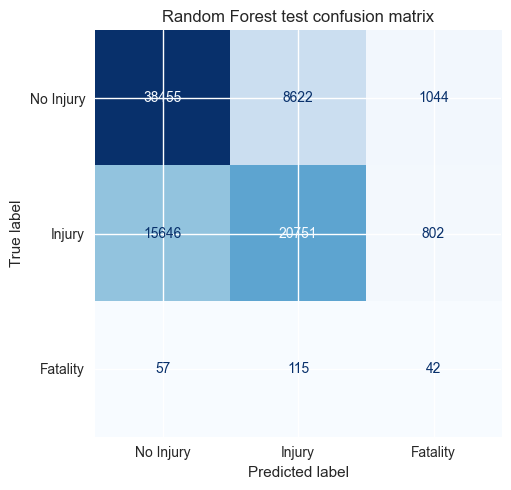

In [19]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Injury', 'Injury', 'Fatality'])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest test confusion matrix')
plt.tight_layout()
plt.show()


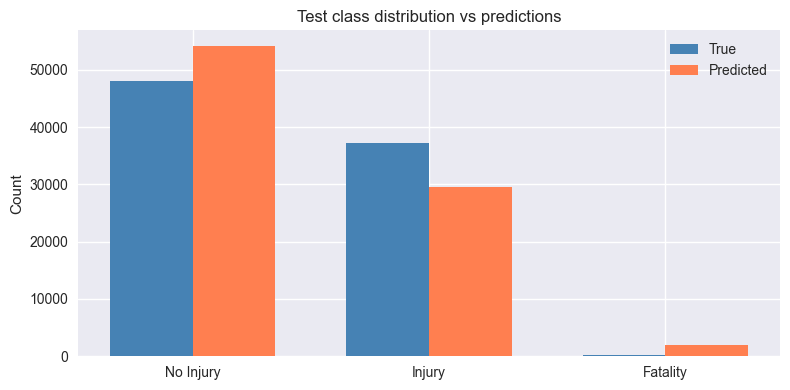

In [20]:
labels = ['No Injury', 'Injury', 'Fatality']
true_counts = y_test.value_counts().sort_index()
pred_counts = pd.Series(y_test_pred).value_counts().sort_index().reindex([0,1,2], fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, true_counts, width, label='True', color='steelblue')
ax.bar(x + width/2, pred_counts, width, label='Predicted', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Count')
ax.set_title('Test class distribution vs predictions')
ax.legend()
plt.tight_layout()
plt.show()


---
## 9. Feature importance

Use permutation importance to measure how much each feature impacts model performance on the test set.


In [ ]:
perm_importance = permutation_importance(
    rf_final, X_test, y_test, scoring='f1_macro', n_repeats=8, random_state=42, n_jobs=-1
)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values(by="importance", ascending=False)
top_features = importance_df.head(12)
print(top_features.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_features["feature"][::-1], top_features["importance"][::-1], xerr=top_features["std"][::-1], color='steelblue')
ax.set_title('Permutation importance — top 12 features')
ax.set_xlabel('Mean decrease in macro F1')
plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (795715894.py, line 13)

---
## 10. Recommendations

- Remove `year` from model inputs and reserve it only for splitting.
- Use derived time and spatial features instead of raw coordinates.
- Prefer permutation importance over impurity importance for clearer feature signals.
- Track Rare Fatality performance explicitly with recall and class-level F1.
- If Fatality recall is still low, try targeted resampling or a specialized ensemble for rare classes.
